## 03 – Permutation enrichment testing: locus-level

**Hypothesis H1 (locus unit):** LTR retrotransposons are enriched at V2R loci relative to chromosome-matched random positions.

This notebook covers:
1. **Distance-decay spatial profile** — repeat density falls off with distance from V2Rs, motivating a local test.
2. **Null A (invalid foil)** — genome-wide shuffle; biologically invalid because V2Rs are non-randomly placed on specific chromosomes.
3. **Null D (valid, locus-level)** — callable-workspace-restricted shuffle, per-chromosome, measuring LTR co-occurrence via the Jaccard index.
4. **Pseudoreplication problem** — tandem V2R paralogs are spatially dependent, inflating locus-level z-scores → motivates cluster-level testing in notebook 04.

Scripts that generated the pre-computed results: `scripts/v2r_priority_analysis.R`, `scripts/v2r_null_d_callable_workspace.R`.

In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import font_manager as fm
from scipy.stats import gaussian_kde
from pathlib import Path
from IPython.display import Image, display, Markdown


# ── paths ──────────────────────────────────────────────────────────────────────────
BASE = "/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs"
OUT  = f"{BASE}/inv/tech-rep/results/priority_analysis"
BINS = f"{BASE}/final-bt/03/repeat_density_gc_mappability_distance_10kb_bins.tsv"

# ── optional serif font (graceful fallback) ─────────────────────────────────────
try:
    fpath = f"{BASE}/inv/tech-rep/assets/fonts/EBGaramond.ttf"
    fm.fontManager.addfont(fpath)
    FONT = fm.FontProperties(fname=fpath).get_name()
    mpl.rcParams.update({"font.family": "serif", "font.serif": [FONT, "DejaVu Serif"]})
except Exception:
    pass  # use matplotlib default

mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.9,
})

BLUE = "#1f4e8c"   # C2 (autosome)
RED  = "#b32020"   # CZ (sex chromosome)
GREY = "#7a7a7a"
PAL  = {"ch2": BLUE, "chZ": RED}
LAB  = {"ch2": "C2 (autosome)", "chZ": "CZ (sex chr.)"}
OBS_BOX = dict(boxstyle="square,pad=0.28", facecolor="white", edgecolor="grey", alpha=1.0)

def sigstar(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

print("Setup done.")

Setup done.


## V2R anchor sets

Three nested V2R confidence tiers were used throughout the analysis:

| Set | Definition | C2 loci | CZ loci |
|-----|-----------|---------|--------|
| Broad (tBLASTn) | All tBLASTn hits to the 7-TM domain | 1,147 | 534 |
| Intact (pHMM) | Structurally intact by profile HMM | 164 | 75 |
| **Primary (intact ∩ tBLASTn)** | pHMM intact + tBLASTn confirmation | **112** | **45** |

**The primary set is used as the anchor throughout permutation testing.**

## Figure 2: Distance-decay spatial profile

**What this shows:** mean total repeat density per 10 kb genomic bin, grouped by distance to the nearest V2R locus.  
Each bin covers 10,000 bp of the reference; repeat density is the fraction of that window covered by annotated repeats (EDTA + RepeatMasker combined).

**Interpretation:**
- Repeat density is highest immediately adjacent to V2R loci (distance ≈ 0) and declines sharply by 25–50 kb.
- The profile is elevated on CZ vs C2 at all distances, consistent with the sex chromosome's higher overall repeat burden.
- The decay to background by ~50 kb motivates the 1, 5, 10, 25 and 50 kb flank sweep used for the dose-response analysis (notebook 05), and confirms that a local test is biologically meaningful.

> Shaded band = 95% CI of the mean per 10 kb bin.

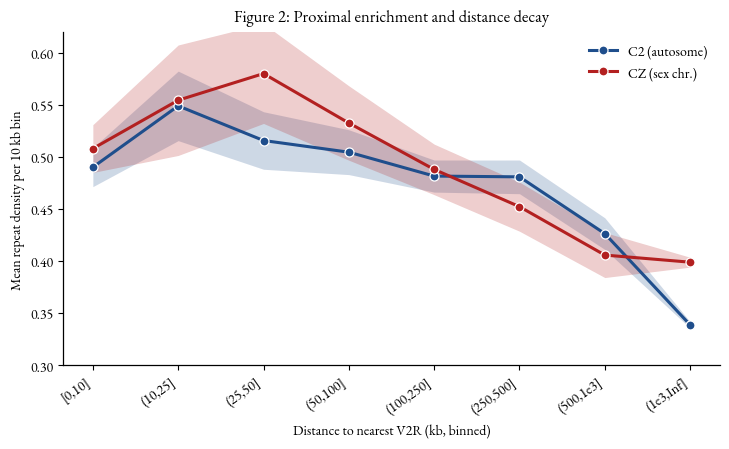

In [2]:
binf = pd.read_csv(BINS, sep="\t")
binf["dist_kb"] = binf["dist_to_v2r"] / 1000.0
edges  = [0, 10, 25, 50, 100, 250, 500, 1000, np.inf]
labels = ["[0,10]", "(10,25]", "(25,50]", "(50,100]",
          "(100,250]", "(250,500]", "(500,1e3]", "(1e3,Inf]"]
binf["dbin"] = pd.cut(binf["dist_kb"], bins=edges, labels=labels, include_lowest=True)
binf = binf.dropna(subset=["dbin", "repeat_density"])

g = (binf.groupby(["chr", "dbin"], observed=True)["repeat_density"]
     .agg(["mean", "sem"]).reset_index())
g["lo"] = g["mean"] - 1.96 * g["sem"]
g["hi"] = g["mean"] + 1.96 * g["sem"]
xi = {lab: i for i, lab in enumerate(labels)}

fig, ax = plt.subplots(figsize=(7.4, 4.6))
for ch in ["ch2", "chZ"]:
    s = g[g["chr"] == ch].set_index("dbin").loc[labels].reset_index()
    x = [xi[b] for b in s["dbin"]]
    ax.fill_between(x, s["lo"], s["hi"], color=PAL[ch], alpha=0.22, lw=0)
    ax.plot(x, s["mean"], color=PAL[ch], lw=2.2, marker="o", ms=6.5,
            mec="white", mew=0.9, label=LAB[ch])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_xlabel("Distance to nearest V2R (kb, binned)", labelpad=6)
ax.set_ylabel("Mean repeat density per 10 kb bin")
ax.set_ylim(0.30, 0.62)
ax.legend(frameon=False, loc="upper right")
ax.set_title("Figure 2: Proximal enrichment and distance decay", pad=8)
fig.tight_layout()
plt.show()

## Null A – genome-wide shuffle (invalid foil)

**What it does:** V2R positions are randomised uniformly across the entire genome (both chromosomes pooled together), then the number of shuffled V2R loci overlapping ≥1 repeat is counted (`numOverlaps`).

**Why it is biologically invalid:**
V2Rs are non-randomly placed — they are concentrated on C2 and CZ, which both happen to be repeat-rich chromosomes in *H. ornatus*. A genome-wide shuffle allows permuted positions to land on *other* chromosomes that have lower repeat content (small autosomes, microchromosomes). This makes the null mean artificially low, inflating the fold enrichment.

The 3.64-fold result is therefore a **chromosome-confound artefact**, not evidence of local LTR enrichment. It is shown here only as a foil to demonstrate the cost of ignoring chromosomal context. All valid tests (Null B–D, Cyclic) restrict permutations to C2 and CZ independently.

*Statistic used:* `numOverlaps` (count of V2R loci overlapping ≥1 repeat; `count.once=TRUE`).

/tmp/ipykernel_3946682/288775977.py:45: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) EB Garamond.
  fig.tight_layout(rect=[0, 0.08, 1, 1])
/hpcfs/users/a1864358/miniconda/envs/general/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) EB Garamond.
  fig.canvas.print_figure(bytes_io, **kw)


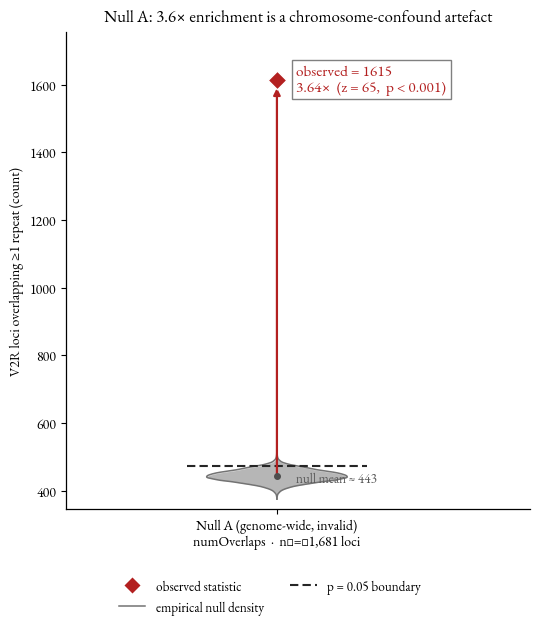

Null A: observed=1615, null mean=443.4, fold=3.64, z=64.7, p=1.0e-04


In [3]:
dA = pd.read_csv(f"{OUT}/original_nullA_numoverlaps_draws.tsv", sep="\t")
mA = pd.read_csv(f"{OUT}/original_nullA_numoverlaps_meta.tsv",  sep="\t").iloc[0]
vA   = dA["value"].to_numpy()
obsA = float(mA["observed"])
muA  = float(mA["null_mean"])
foldA = obsA / muA
critA = np.quantile(vA, 0.95)
p1A   = (np.sum(vA >= obsA) + 1) / (len(vA) + 1)

fig, ax = plt.subplots(figsize=(5.5, 6.2))
vp = ax.violinplot([vA], positions=[0], widths=0.5, showextrema=False)
for b in vp["bodies"]:
    b.set_facecolor(GREY); b.set_alpha(0.55); b.set_edgecolor("white")
ys   = np.linspace(vA.min(), vA.max(), 256)
dens = gaussian_kde(vA)(ys); dens = dens / dens.max() * 0.25
ax.plot(0 + dens, ys, color="0.45", lw=1.1)
ax.plot(0 - dens, ys, color="0.45", lw=1.1)
ax.hlines(critA, -0.32, 0.32, color="0.15", lw=1.5, ls=(0, (4, 2)))
ax.annotate("", xy=(0, obsA), xytext=(0, muA),
            arrowprops=dict(arrowstyle="-|>", color=RED, lw=1.6, shrinkA=0, shrinkB=6))
ax.scatter(0, obsA, marker="D", s=90, color=RED, edgecolor="white", lw=1.0, zorder=10)
ax.scatter(0, muA, s=16, color="0.3", zorder=7)
ax.annotate(
    f"observed = {obsA:.0f}\n{foldA:.2f}\u00d7  (z = {float(mA['z']):.0f},  p < 0.001)",
    (0, obsA), textcoords="offset points", xytext=(14, 0), va="center",
    fontsize=11, color=RED, fontweight="heavy", bbox=OBS_BOX, zorder=11,
)
ax.annotate(f"null mean \u2248 {muA:.0f}", (0, muA),
            textcoords="offset points", xytext=(14, -2), va="center",
            fontsize=9.5, color="0.35")
ax.set_xticks([0])
ax.set_xticklabels(["Null A (genome-wide, invalid)\nnumOverlaps  ·  n\u202f=\u202f1,681 loci"])
ax.set_xlim(-0.75, 0.9)
ax.set_ylim(min(vA.min() - 30, muA - 30), obsA + 140)
ax.set_ylabel("V2R loci overlapping \u22651 repeat (count)")
ax.set_title("Null A: 3.6\u00d7 enrichment is a chromosome-confound artefact", pad=8)
handles = [
    Line2D([0],[0], marker="D", color=RED, lw=0, markeredgecolor="white", ms=9,
           label="observed statistic"),
    Line2D([0],[0], color="0.45", lw=1.1, label="empirical null density"),
    Line2D([0],[0], color="0.15", lw=1.5, ls=(0,(4,2)), label="p = 0.05 boundary"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=2, frameon=False, fontsize=9.5)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print(f"Null A: observed={obsA:.0f}, null mean={muA:.1f}, fold={foldA:.2f}, "
      f"z={float(mA['z']):.1f}, p={p1A:.1e}")

## Null D (locus-level, valid): callable workspace + Jaccard index

### What is the callable workspace?

The callable workspace is the set of genomic positions where a real V2R gene *could plausibly be annotated*. It excludes three types of unreliable regions:

| Mask component | Definition | Why excluded |
|----------------|-----------|-------------|
| Assembly gaps | Runs of N nucleotides | No real sequence; random placement is meaningless |
| Low-mappability bins | 1 Mb windows where mean GenMap K30 E2 < 10th percentile | Short-read alignments unreliable; genes cannot be confidently called |
| Coverage-anomaly bins | 1 Mb bins where read depth deviates > 3σ from the chromosome median | Likely misassembly or collapsed repeats; gene boundaries unreliable |

Restricting permuted positions to the callable workspace prevents the null from landing in genomic '_deserts_' where LTR density would be artificially low, which would otherwise inflate enrichment by lowering the null mean.

**V2R bins vs background bins**

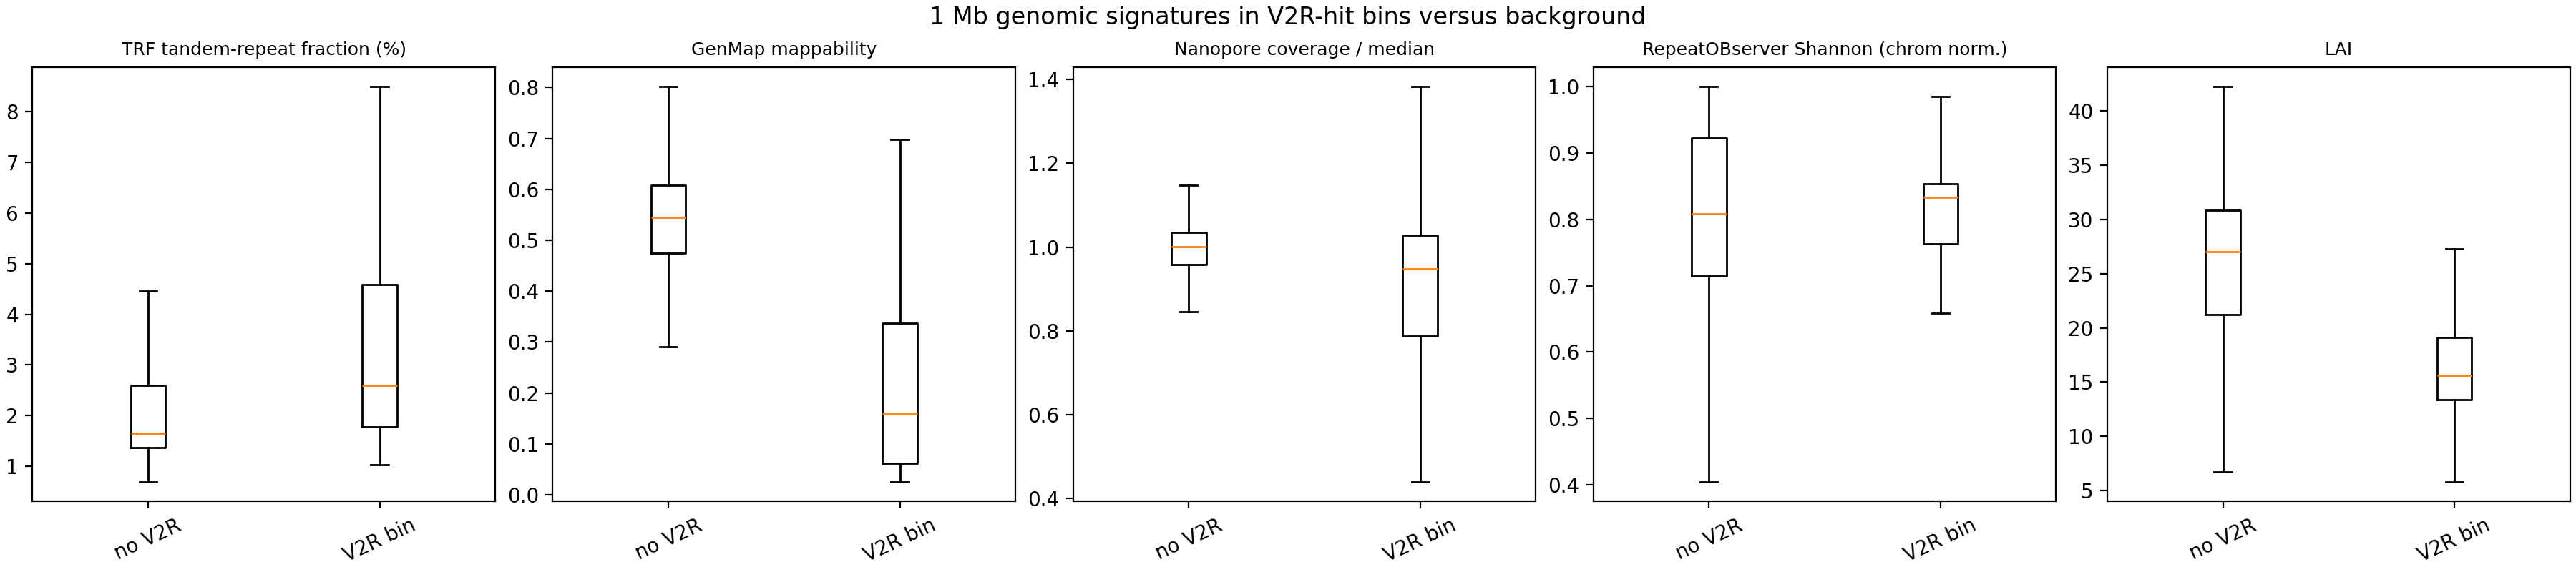

  ← /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/03/v2r_vs_background_track_boxplots.png


**Binary signature enrichment**

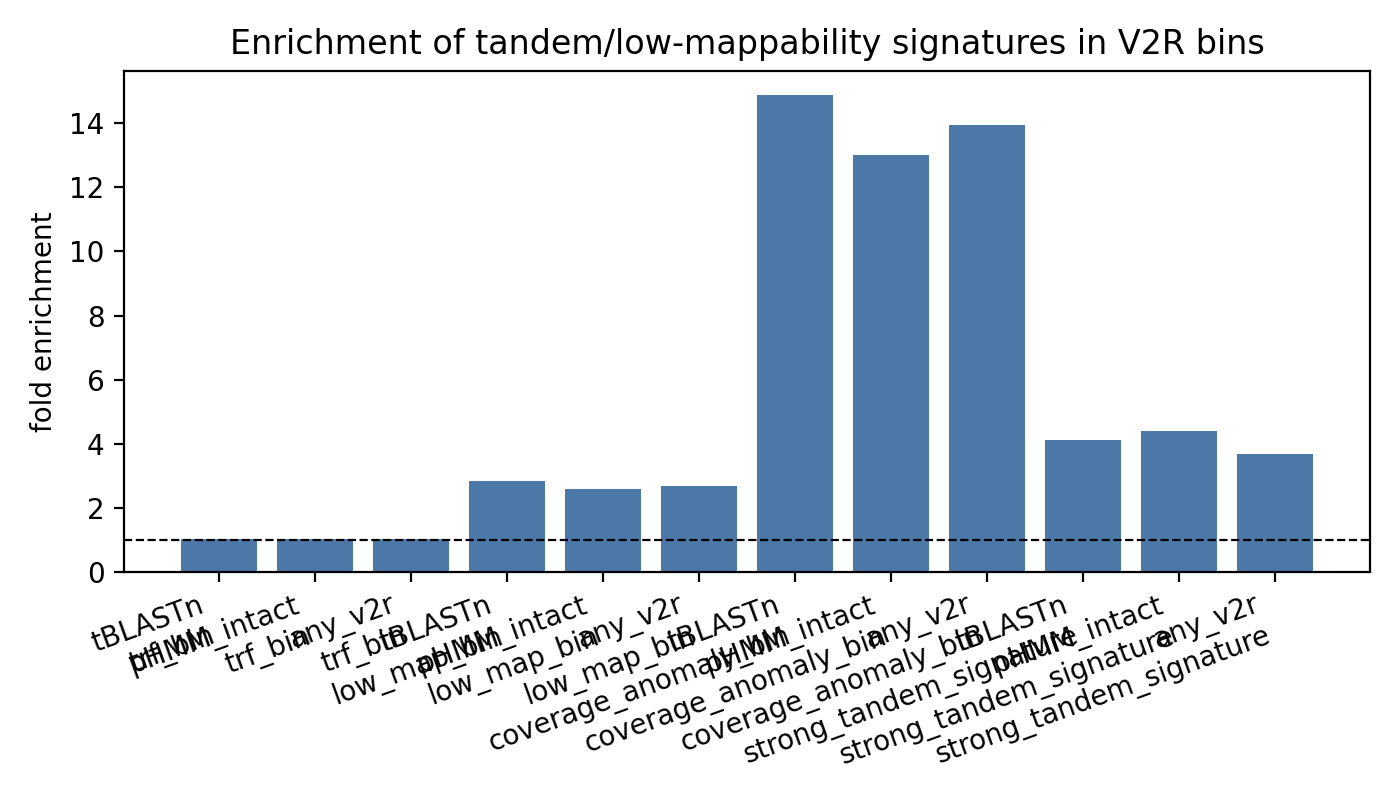

  ← /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/03/v2r_bin_signature_enrichment.png


**Distance gradient from nearest V2R bin**

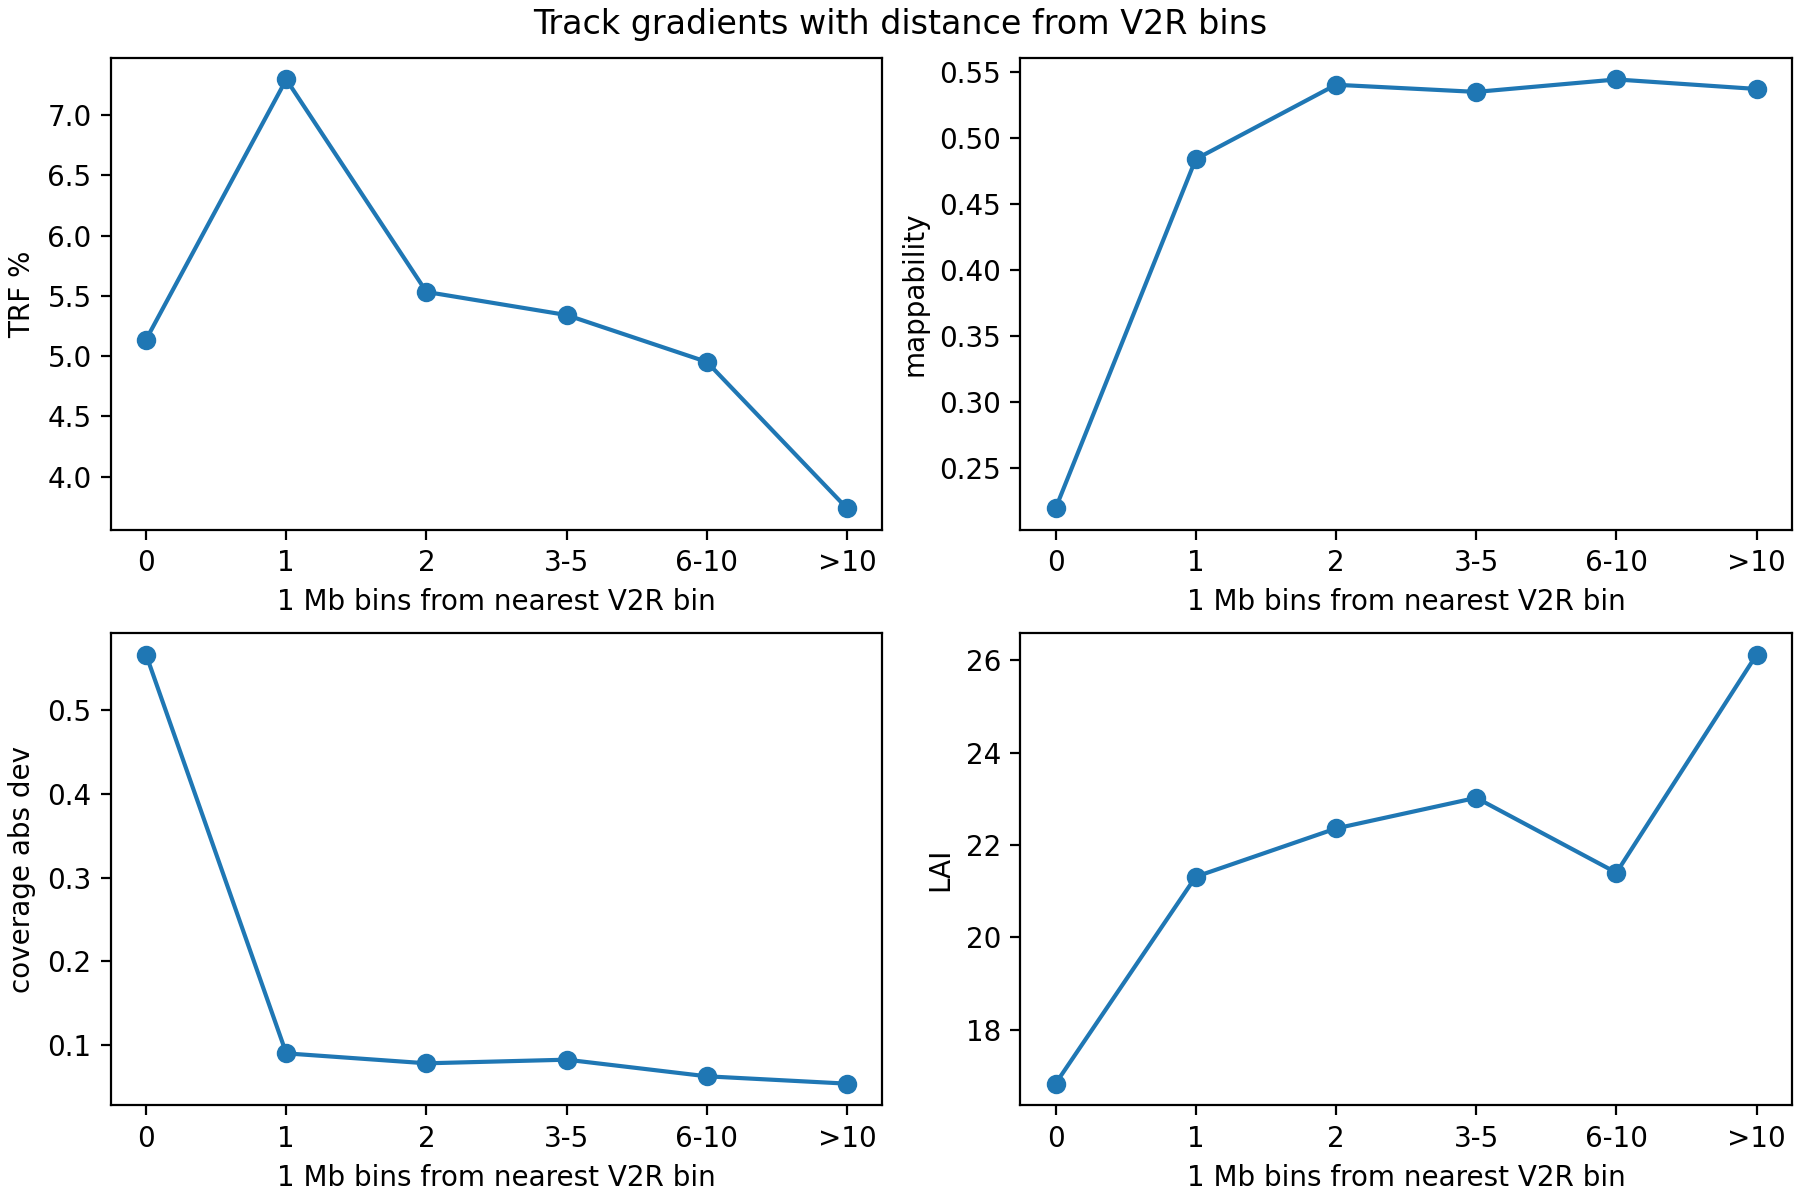

  ← /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/03/track_gradients_distance_to_v2r.png


**ch2/chZ tandem-signal genome tracks**

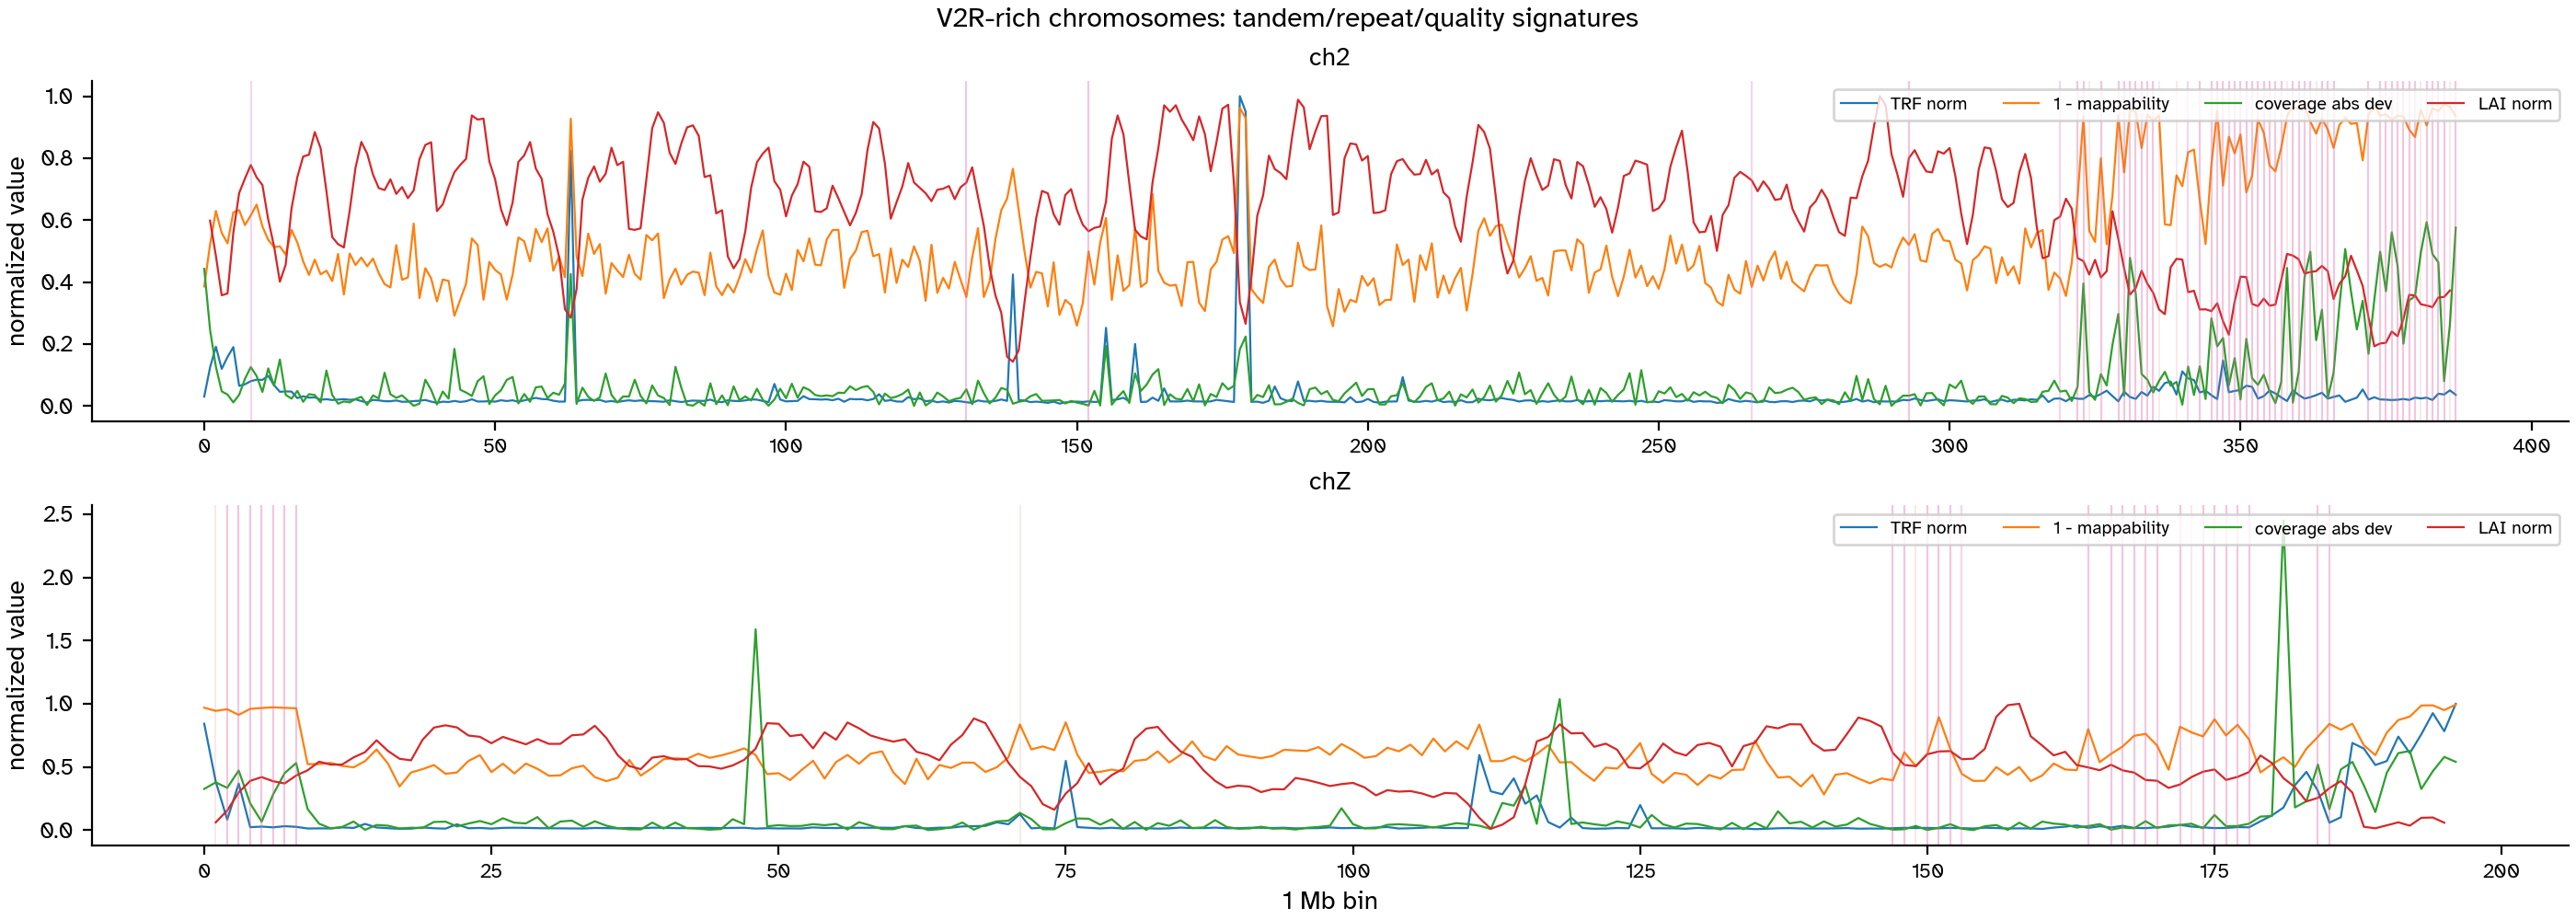

  ← /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/03/ch2_chZ_v2r_tandem_signal_tracks.png


In [13]:

BT = Path('/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt')
POC = Path('/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/inv/tech-rep/results/poc_v2rs_complexity')
PRIORITY = Path('/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/inv/tech-rep/results/priority_analysis')

ROOT = BT / 'poc_v2rs_complexity'
FIG = ROOT / 'figures'
DATA = POC / 'data'  
FIG.mkdir(parents=True, exist_ok=True)

FIG_DIRS = [
    BT / '03',
    FIG,
    POC / 'figures',
]

def find_fig(name: str) -> Path:
    for d in FIG_DIRS:
        p = d / name
        if p.exists():
            return p
    raise FileNotFoundError(f'{name} not found in: ' + ', '.join(str(d) for d in FIG_DIRS))

def show(name, title=None, width=900):
    path = find_fig(name)
    if title:
        display(Markdown(f'**{title}**'))
    display(Image(filename=str(path), width=width))
    print(f'  ← {path}')

for name, title in [
    ('v2r_vs_background_track_boxplots.png', 'V2R bins vs background bins'),
    ('v2r_bin_signature_enrichment.png', 'Binary signature enrichment'),
    ('track_gradients_distance_to_v2r.png', 'Distance gradient from nearest V2R bin'),
    ('ch2_chZ_v2r_tandem_signal_tracks.png', 'ch2/chZ tandem-signal genome tracks'),
]:
    show(name, title)



### What is the Jaccard index?

For locus-level overlap (single gene positions, not merged clusters), the Jaccard base-pair index is preferred:

$$\text{Jaccard} = \frac{|\text{LTR} \cap \text{V2R}|}{|\text{LTR} \cup \text{V2R}|}$$

Unlike `numOverlaps` (which is a binary count), Jaccard accounts for the *extent* of overlap relative to the *total* genomic footprint. This prevents large V2R loci from contributing disproportionate overlap just by being wide.

### Why does locus-level still have a problem?

Even with a valid null (Null D), locus-level testing suffers from **spatial pseudoreplication**: V2R paralogs within tandem arrays are separated by only 2–50 kb and therefore sample the same genomic neighbourhood. Each paralog is not an independent observation. Treating them as independent inflates the effective sample size, producing spuriously large z-scores.


<>:53: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:53: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/tmp/ipykernel_3946682/4199600475.py:53: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  "Null distribution approximated as N(null\_mean, null\_sd);  n\u202f=\u202f10,000 permutations in R",


/tmp/ipykernel_3946682/4199600475.py:58: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) EB Garamond.
  fig.tight_layout(rect=[0, 0.07, 1, 0.94])


/hpcfs/users/a1864358/miniconda/envs/general/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) EB Garamond.
  fig.canvas.print_figure(bytes_io, **kw)


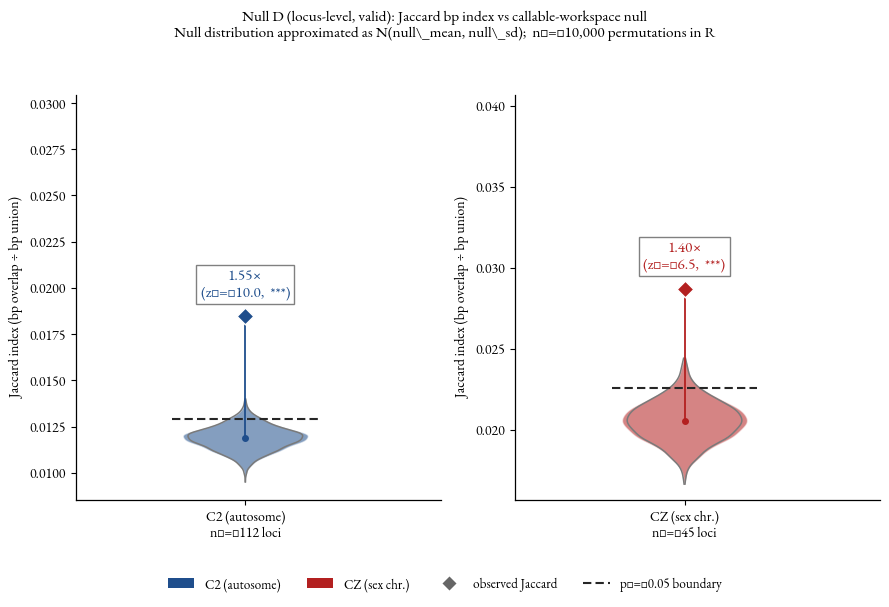

Null D locus-level results (D_core_lowmap_cov, Jaccard bp):
  C2: obs=0.01846, null_mean=0.01190, fold=1.551, z=10.03, p<0.001
  CZ: obs=0.02870, null_mean=0.02051, fold=1.400, z=6.49, p<0.001


In [4]:
# Null D locus-level results (from null_d_callable_workspace_ltr_tests.tsv, D_core_lowmap_cov)
# These values match Figure 4C of the tech report.
ND = {
    "ch2": dict(obs=0.018462656744894, null_mean=0.0119007444826447,
                z=10.0279, fold=1.5513867028923, n=112),
    "chZ": dict(obs=0.0287039284108161, null_mean=0.0205082664325468,
                z=6.4854,  fold=1.39962724324971, n=45),
}
rng = np.random.default_rng(42)
for ch, d in ND.items():
    d["null_sd"]  = (d["obs"] - d["null_mean"]) / d["z"]
    d["null_sim"] = rng.normal(d["null_mean"], d["null_sd"], 2000)
    d["crit95"]   = np.quantile(d["null_sim"], 0.95)
    d["p1"]       = (np.sum(d["null_sim"] >= d["obs"]) + 1) / (len(d["null_sim"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 6), sharey=False)
for ax, ch in zip(axes, ["ch2", "chZ"]):
    d  = ND[ch]
    v  = d["null_sim"]
    vp = ax.violinplot([v], positions=[0], widths=0.48, showextrema=False)
    for b in vp["bodies"]:
        b.set_facecolor(PAL[ch]); b.set_alpha(0.55); b.set_edgecolor("white")
    ys = np.linspace(v.min(), v.max(), 256)
    dn = gaussian_kde(v)(ys); dn = dn / dn.max() * 0.22
    ax.plot(0 + dn, ys, color=GREY, lw=1.1)
    ax.plot(0 - dn, ys, color=GREY, lw=1.1)
    ax.hlines(d["crit95"], -0.28, 0.28, color="0.15", lw=1.5, ls=(0, (4, 2)))
    ax.plot([0, 0], [d["null_mean"], d["obs"]], color=PAL[ch], lw=1.3)
    ax.scatter(0, d["null_mean"], s=16, color=PAL[ch], zorder=6)
    ax.scatter(0, d["obs"], marker="D", s=72, color=PAL[ch],
               edgecolor="white", lw=1.0, zorder=10)
    ax.annotate(
        f"{d['fold']:.2f}\u00d7\n(z\u202f=\u202f{d['z']:.1f},  ***)",
        (0, d["obs"]), textcoords="offset points", xytext=(0, 12),
        ha="center", va="bottom", fontsize=11, color=PAL[ch],
        fontweight="heavy", bbox=OBS_BOX, zorder=11,
    )
    ax.set_xticks([0])
    ax.set_xticklabels([f"{LAB[ch]}\nn\u202f=\u202f{d['n']} loci"])
    ax.set_xlim(-0.65, 0.75)
    ax.set_ylim(v.min() - 0.001, d["obs"] + 0.012)
    ax.set_ylabel("Jaccard index (bp overlap \u00f7 bp union)")

handles = [
    Patch(facecolor=BLUE, label="C2 (autosome)"),
    Patch(facecolor=RED,  label="CZ (sex chr.)"),
    Line2D([0],[0], marker="D", color="0.4", lw=0, markeredgecolor="white", ms=8,
           label="observed Jaccard"),
    Line2D([0],[0], color="0.15", lw=1.5, ls=(0,(4,2)), label="p\u202f=\u202f0.05 boundary"),
]
fig.suptitle(
    "Null D (locus-level, valid): Jaccard bp index vs callable-workspace null\n"
    "Null distribution approximated as N(null\_mean, null\_sd);  n\u202f=\u202f10,000 permutations in R",
    fontsize=11,
)
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.01),
           ncol=4, frameon=False, fontsize=9.5)
fig.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()

print("Null D locus-level results (D_core_lowmap_cov, Jaccard bp):")
for ch, d in ND.items():
    lab = {"ch2":"C2","chZ":"CZ"}[ch]
    print(f"  {lab}: obs={d['obs']:.5f}, null_mean={d['null_mean']:.5f}, "
          f"fold={d['fold']:.3f}, z={d['z']:.2f}, p<0.001")

## Pseudoreplication problem → cluster-level testing

Both C2 and CZ show significant Null D enrichment at the locus level (C2: 1.55×, z = 10.03; CZ: 1.40×, z = 6.49; both p < 0.001). However, these z-scores are likely inflated by **spatial pseudoreplication**.

Tandem V2R paralogs within the same gene array are separated by only 2–98 kb (median 33 kb for intra-array gaps). Shuffling each locus independently treats them as statistically independent — but they are not: adjacent paralogs see the same local repeat landscape. This inflates the effective n and consequently the z-score.

**Solution:** merge adjacent V2Rs into clusters, then treat each *cluster* as the unit of observation and repeat the permutation tests.

- 100 kb threshold collapses 112 loci → **73 clusters** on C2 and 45 → **29 clusters** on CZ.
- The cluster merge threshold was validated by checking that results are qualitatively identical at 25, 50 and 100 kb merges.
